Revised Proposal:


Biological Question:
How do specific craniofacial developmnent pathways (FGF, BMP, Wnt) show gene expression patterns in cranial neural crest-derived soft palate cells across developmnent stages (E13.5, E14.5, E15.5)? 
I aim to focus on a few representative genes from each pathway (for example, FGFR2 for FGF, BMP2, for BMP, and WNT5A for Wnt to observe how their expression changes during normal soft palate development. 

Data:
I will use publicly available single -cell RNA-seq from a Runx2-Twist1 study. 
This dataset includes raw read counts and preprocessed Seurat objects for each stage. 

Analysis Plan:
For each developmental stage, I will: 

    1. Load single-cell RNA-seq data into python using scanpy.
    2. Identify CNC-derived cell populations based on clustering (already annotated in Seurat if pssible). 
    3. Extract expression data for the chosen genes in FGF, BMP, and Wnt pathways. 
    4. Compare expression levels across stages to see developmental trends. 
    5. Generate visualizations for each gene or pathway. 
        -Violin plots to show distribution of gene expression across cells. 
        -Heatmaps to show expression patterns across stages.
        -UMAP plots to visualize where these genes are expressed in the cell clusters. 
        
Tools:
I will use python with: 
    -scanpy for single-cell RNA-seq data analysis
    -pandas and numpy for data manipulation
    -matplotlib and seaborn for visualization 
    

Dataset:
https://www.facebase.org/chaise/record/#1/isa:dataset/RID=1-X280 - TGF-β / RUNX2 

Tools: 
1. pandas
2. numpy
3. matplotlib
4. seaborn
5. scanpy

In [25]:
# import packages 

import scanpy as sc
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [46]:
folder_path = '/Users/aminatafofana/Downloads'

In [28]:
# Make sure the Seurat gz files for each stage are downloaded and unzipped, start with E13.5

# Load the matrix files 
adata = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE135control", var_names='gene_symbols', cache=True)

print(adata)


AnnData object with n_obs × n_vars = 7381 × 31053
    var: 'gene_ids', 'feature_types'


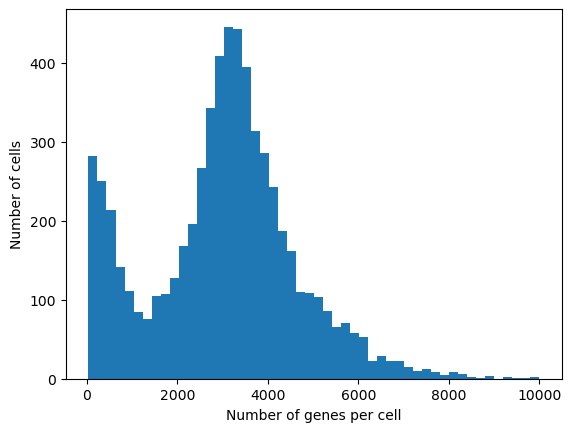

In [54]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Quick look @ distributions 

#Histogram for genes per cells 
plt.hist(adata.obs['n_genes_by_counts'], bins=50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells') 
plt.show()





/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


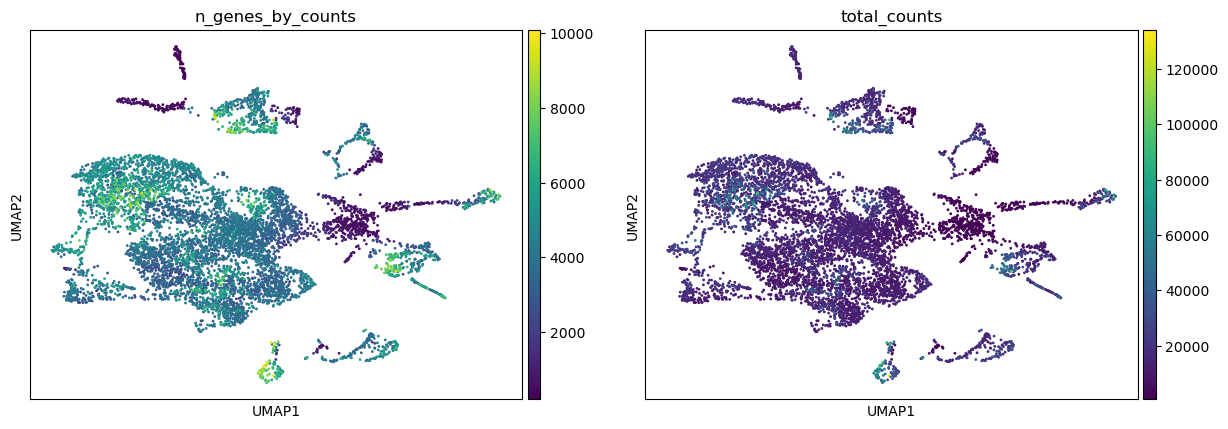

In [34]:
#Filter cells and genes - removes low-quality cells, removes genes expressed in almost no cells, reduces noise 
adata = adata[adata.obs['n_genes_by_counts'] >=200, :] # cells with > 200 genes 
adata = adata[:, adata.var['n_cells_by_counts'] >=3]

#Normalize total counts per cell to 10,000 then log-transform - scales each cell to the same total counts (10,000 is the standard), log1p makes the gene expression distributions more comparable and stabilizes variance 
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

#identify highly variable genes - only select the top 2,000 genes that vary the most across cells, should improve PCA and clustering 
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

#scale the data - centers gene to mean 0 and variance of 1, prevents highly expressed genes from dominating, max_value=10 avoids extremely high values, preventing skewed results 
sc.pp.scale(adata, max_value= 10) 

#PCA
sc.tl.pca(adata, svd_solver='arpack')

#compute neighborhood graph- defines which cells are "neighbors" based on PCA, neighbors=10 is standard for small datasets, pcs=20 uses the first 20 PCs 
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

#UMAP
sc.tl.umap(adata) 
sc.pl.umap(adata, color=['n_genes_by_counts', 'total_counts'])

Fgf8 found
Fgfr2 found
Bmp4 found
Bmpr1a found
Wnt5a found
Fzd7 found


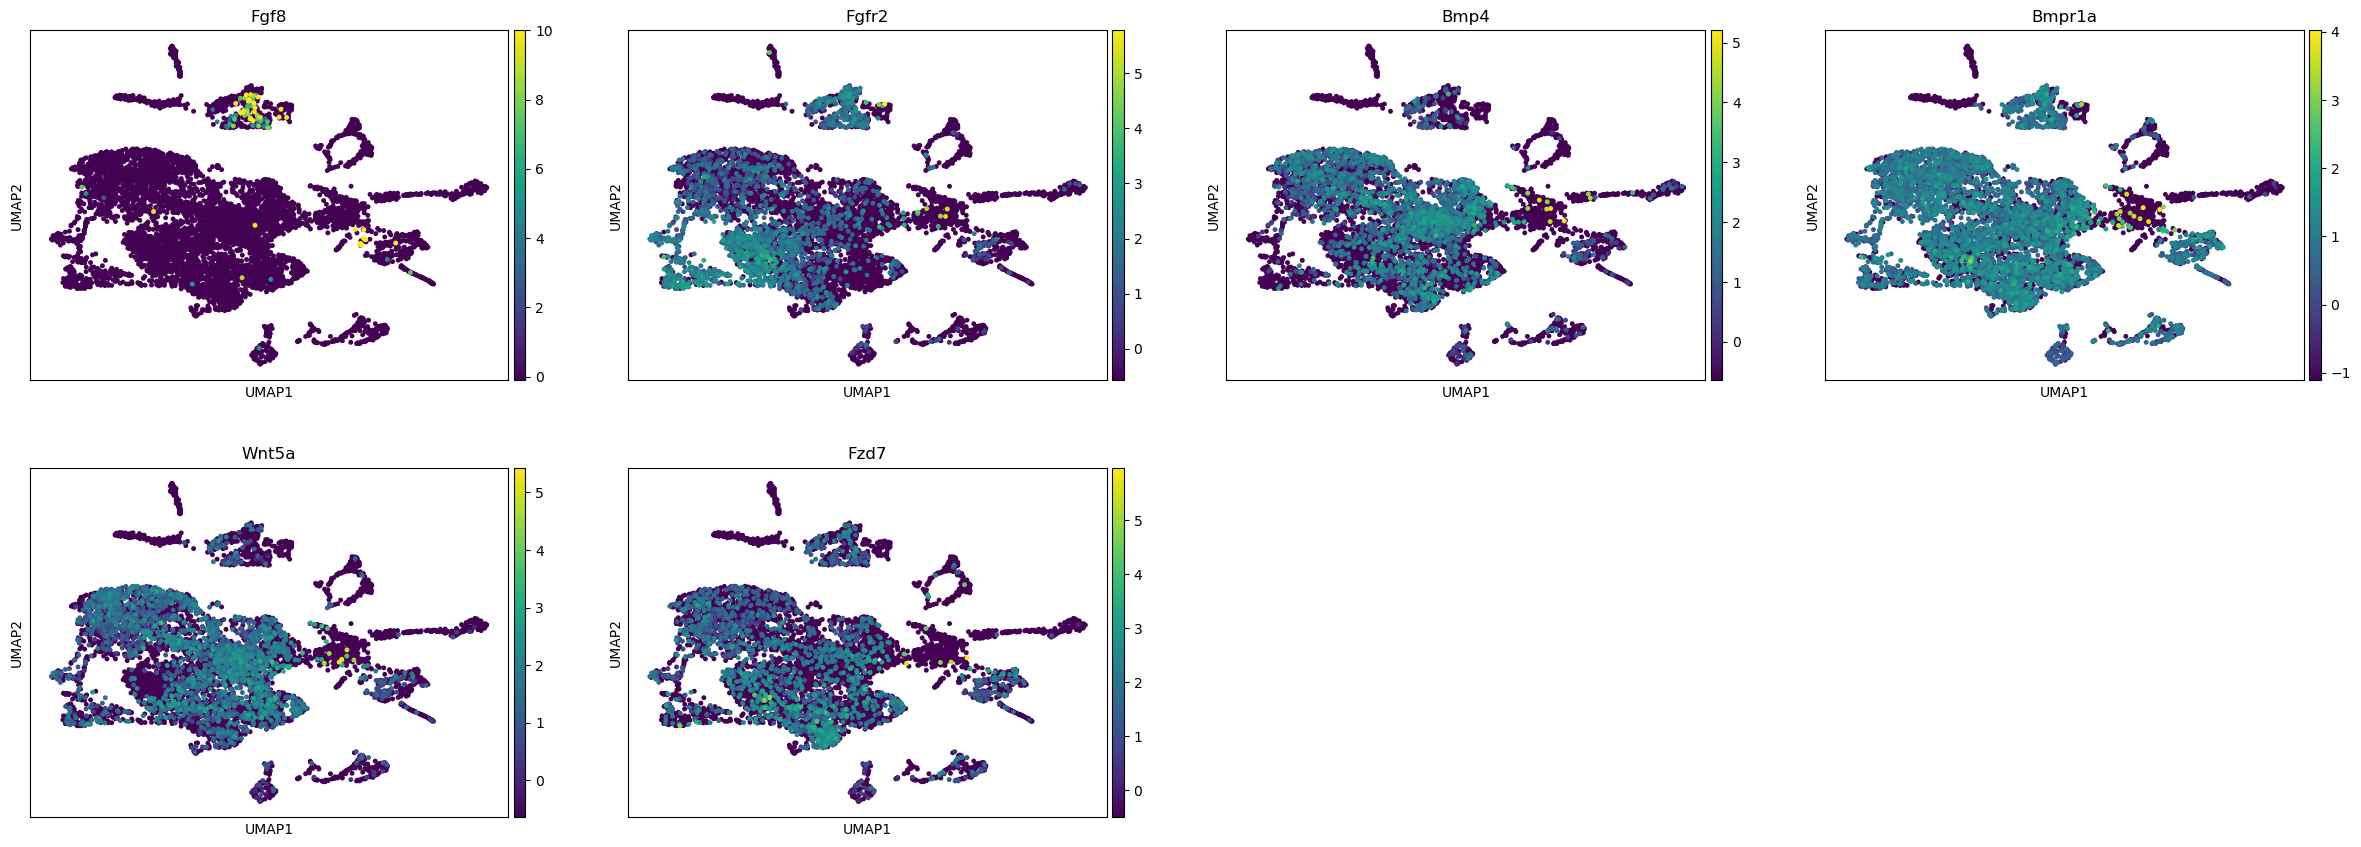

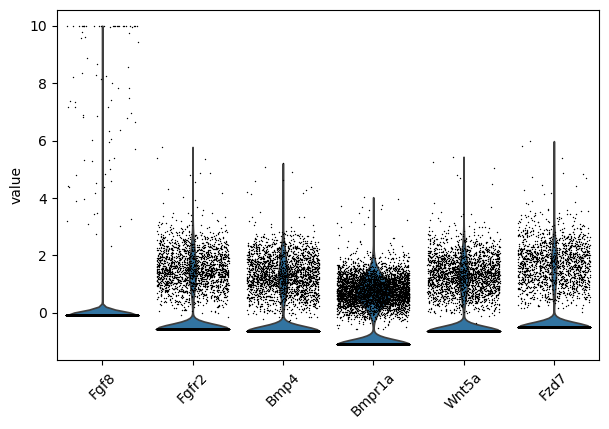

In [37]:
#Defining genes of interest 
    #FGF pathway: Fgf8, Fgfr2
    #BMP pathway: Bmp4, Bmpr1a
    #Wnt pathway: Wnt5a, Fzd7

#list genes of interest 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in my Anndata object 
for gene in genes_of_interest: 
    if gene not in adata.var_names: 
        print(f"{gene} not found")
    else: 
        print(f"{gene} found")

# Visualize expression of the genes on the UMAP 
sc.pl.umap(adata, color=genes_of_interest, cmap='viridis', size=50)

#Violin plot show distribution of expression per gene
sc.pl.violin(adata, genes_of_interest, jitter=0.4, rotation=45)


     Gene  AverageExpression
0    Fgf8      -1.091898e-02
1   Fgfr2       3.585174e-17
2    Bmp4      -2.422415e-17
3  Bmpr1a      -6.637417e-17
4   Wnt5a       3.488277e-17
5    Fzd7      -9.810780e-17


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_27132/1976659830.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gene', y='AverageExpression', data=avg_expr_df, palette='viridis', legend=False)


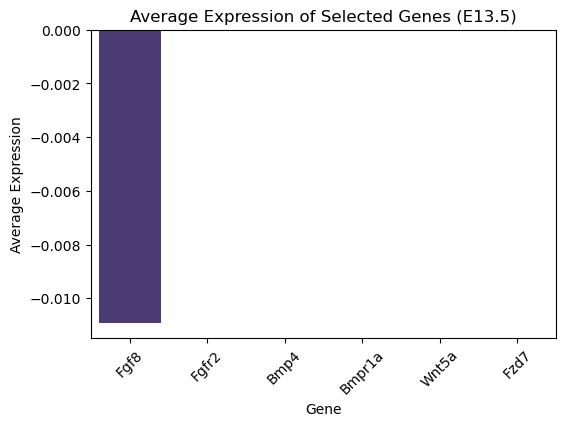

In [42]:
# calculate mean expression for each gene in list 
avg_expression = adata[:, genes_of_interest].X.mean(axis=0)

#convert to a pandas Dataframe for easy viewing 
avg_expr_df = pd.DataFrame({'Gene': genes_of_interest, 'AverageExpression': avg_expression.flatten()})
 

print(avg_expr_df)

#optional barplot for easy viewing 

plt.figure(figsize=(6,4))
sns.barplot(x='Gene', y='AverageExpression', data=avg_expr_df, palette='viridis', legend=False)

plt.title('Average Expression of Selected Genes (E13.5)')
plt.ylabel('Average Expression')
plt.xlabel('Gene')
plt.xticks(rotation=45)
plt.show()


AnnData object with n_obs × n_vars = 6190 × 31053
    var: 'gene_ids', 'feature_types'


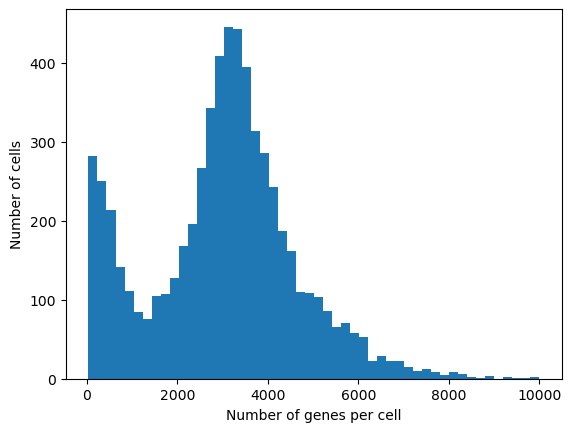

/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


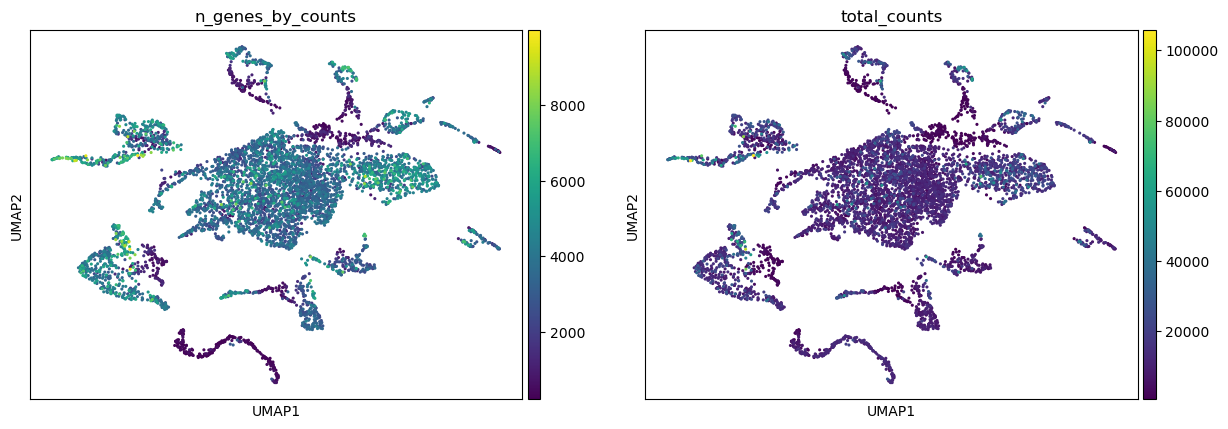

In [61]:
# same worflow for samples E14.5 


adata_2= sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE145control", var_names='gene_symbols', cache=True)

print(adata_2)



# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_2, inplace=True)

# Quick look @ distributions 

#Histogram for genes per cells 
plt.hist(adata_2.obs['n_genes_by_counts'], bins=50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells') 
plt.show()

#Filter cells and genes - removes low-quality cells, removes genes expressed in almost no cells, reduces noise 
adata_2 = adata_2[adata_2.obs['n_genes_by_counts'] >=200, :] # cells with > 200 genes 
adata_2 = adata_2[:, adata_2.var['n_cells_by_counts'] >=3]

#Normalize total counts per cell to 10,000 then log-transform - scales each cell to the same total counts (10,000 is the standard), log1p makes the gene expression distributions more comparable and stabilizes variance 
sc.pp.normalize_total(adata_2, target_sum=1e4)
sc.pp.log1p(adata_2)

#identify highly variable genes - only select the top 2,000 genes that vary the most across cells, should improve PCA and clustering 
sc.pp.highly_variable_genes(adata_2, n_top_genes=2000)

#scale the data - centers gene to mean 0 and variance of 1, prevents highly expressed genes from dominating, max_value=10 avoids extremely high values, preventing skewed results 
sc.pp.scale(adata_2, max_value= 10) 

#PCA
sc.tl.pca(adata_2, svd_solver='arpack')

#compute neighborhood graph- defines which cells are "neighbors" based on PCA, neighbors=10 is standard for small datasets, pcs=20 uses the first 20 PCs 
sc.pp.neighbors(adata_2, n_neighbors=10, n_pcs=20)

#UMAP
sc.tl.umap(adata_2) 
sc.pl.umap(adata_2, color=['n_genes_by_counts', 'total_counts'])






Fgf8 found
Fgfr2 found
Bmp4 found
Bmpr1a found
Wnt5a found
Fzd7 found


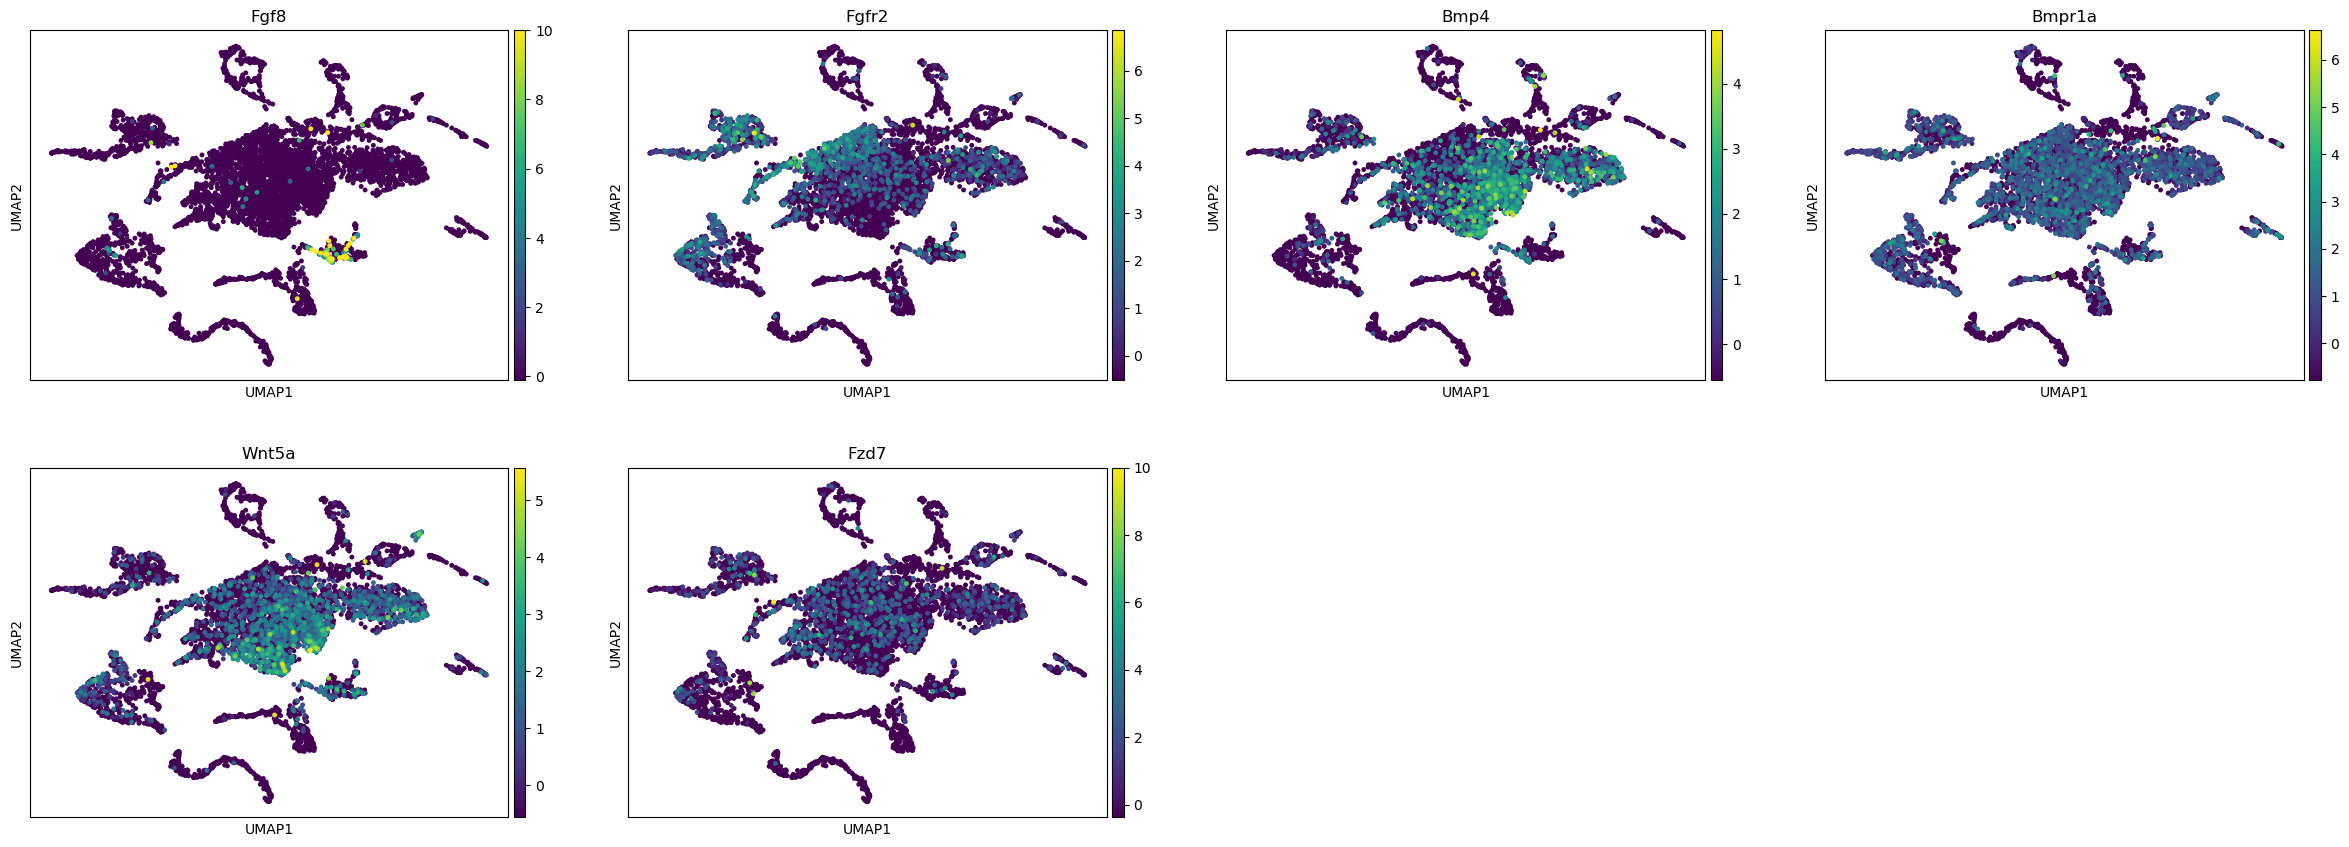

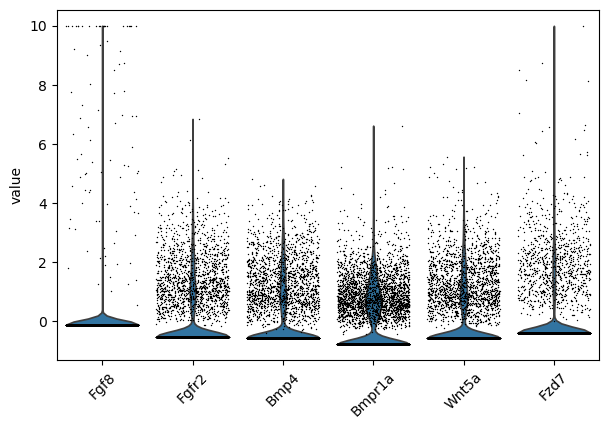

In [60]:
#list genes of interest 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in my Anndata object 
for gene in genes_of_interest: 
    if gene not in adata_2.var_names: 
        print(f"{gene} not found")
    else: 
        print(f"{gene} found")

#Visualize expression of the genes on the UMAP
sc.pl.umap(adata_2, color=genes_of_interest, cmap='viridis', size=50)

#Violin plot show distribution of expression per gene
sc.pl.violin(adata_2, genes_of_interest, jitter=0.4, rotation=45)


     Gene  AverageExpression
0    Fgf8      -1.091145e-02
1   Fgfr2      -2.506113e-17
2    Bmp4       2.625452e-17
3  Bmpr1a      -1.193387e-17
4   Wnt5a       1.014379e-17
5    Fzd7      -8.119351e-05


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_27132/4193546079.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gene', y='AverageExpression', data=avg_expr_df, palette='viridis', legend=False)


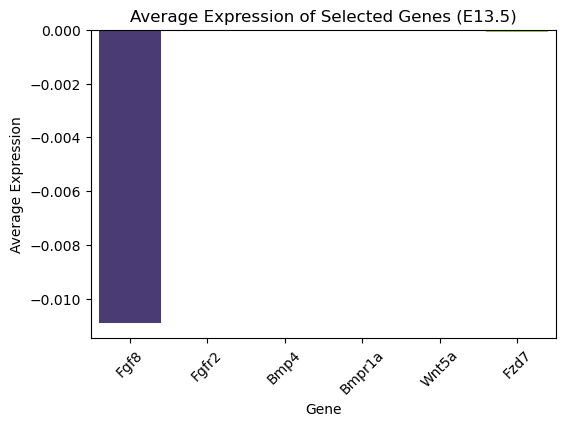

In [62]:
# calculate mean expression for each gene in list 
avg_expression = adata_2[:, genes_of_interest].X.mean(axis=0)

#convert to a pandas Dataframe for easy viewing 
avg_expr_df = pd.DataFrame({'Gene': genes_of_interest, 'AverageExpression': avg_expression.flatten()})

print(avg_expr_df)

#optional barplot for easy viewing 

plt.figure(figsize=(6,4))
sns.barplot(x='Gene', y='AverageExpression', data=avg_expr_df, palette='viridis', legend=False)

plt.title('Average Expression of Selected Genes (E13.5)')
plt.ylabel('Average Expression')
plt.xlabel('Gene')
plt.xticks(rotation=45)
plt.show()

 

AnnData object with n_obs × n_vars = 6899 × 31053
    var: 'gene_ids', 'feature_types'


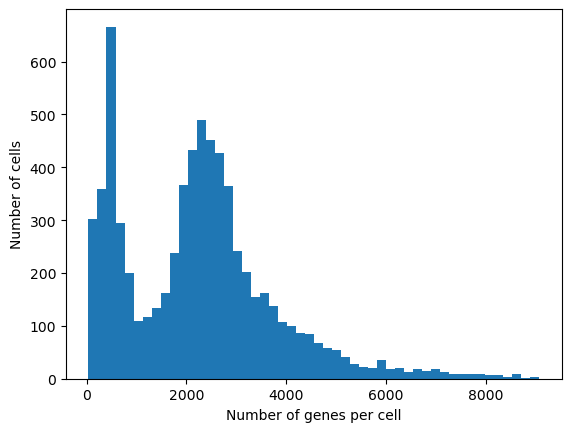

In [63]:
# same workflow for sample 15.5 


adata_3= sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE155control", var_names='gene_symbols', cache=True)

print(adata_3)



# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_3, inplace=True)

# Quick look @ distributions 

#Histogram for genes per cells 
plt.hist(adata_3.obs['n_genes_by_counts'], bins=50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells') 
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


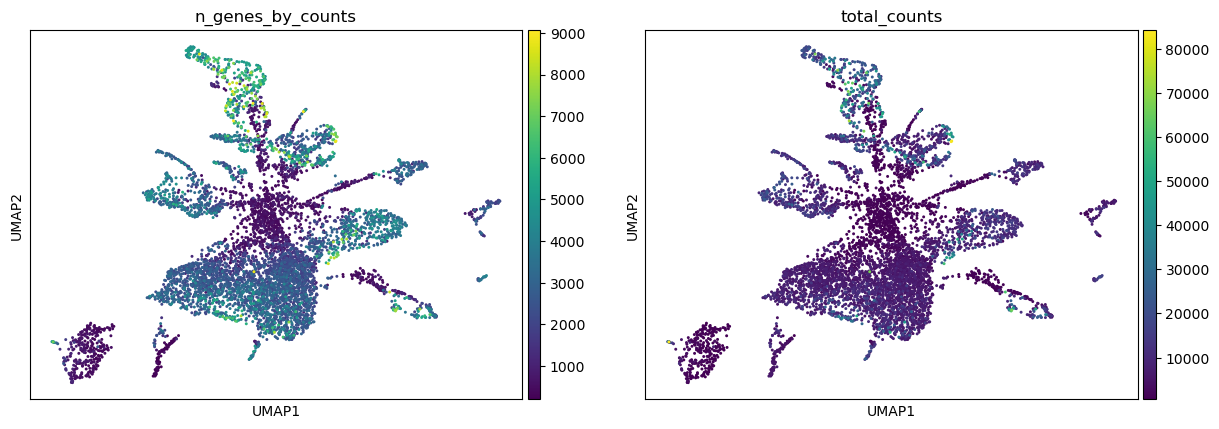

In [64]:
#Filter cells and genes - removes low-quality cells, removes genes expressed in almost no cells, reduces noise 
adata_3 = adata_3[adata_3.obs['n_genes_by_counts'] >=200, :] # cells with > 200 genes 
adata_3 = adata_3[:, adata_3.var['n_cells_by_counts'] >=3]

#Normalize total counts per cell to 10,000 then log-transform - scales each cell to the same total counts (10,000 is the standard), log1p makes the gene expression distributions more comparable and stabilizes variance 
sc.pp.normalize_total(adata_3, target_sum=1e4)
sc.pp.log1p(adata_3)

#identify highly variable genes - only select the top 2,000 genes that vary the most across cells, should improve PCA and clustering 
sc.pp.highly_variable_genes(adata_3, n_top_genes=2000)

#scale the data - centers gene to mean 0 and variance of 1, prevents highly expressed genes from dominating, max_value=10 avoids extremely high values, preventing skewed results 
sc.pp.scale(adata_3, max_value= 10) 

#PCA
sc.tl.pca(adata_3, svd_solver='arpack')

#compute neighborhood graph- defines which cells are "neighbors" based on PCA, neighbors=10 is standard for small datasets, pcs=20 uses the first 20 PCs 
sc.pp.neighbors(adata_3, n_neighbors=10, n_pcs=20)

#UMAP
sc.tl.umap(adata_3) 
sc.pl.umap(adata_3, color=['n_genes_by_counts', 'total_counts'])


Fgf8 found
Fgfr2 found
Bmp4 found
Bmpr1a found
Wnt5a found
Fzd7 found


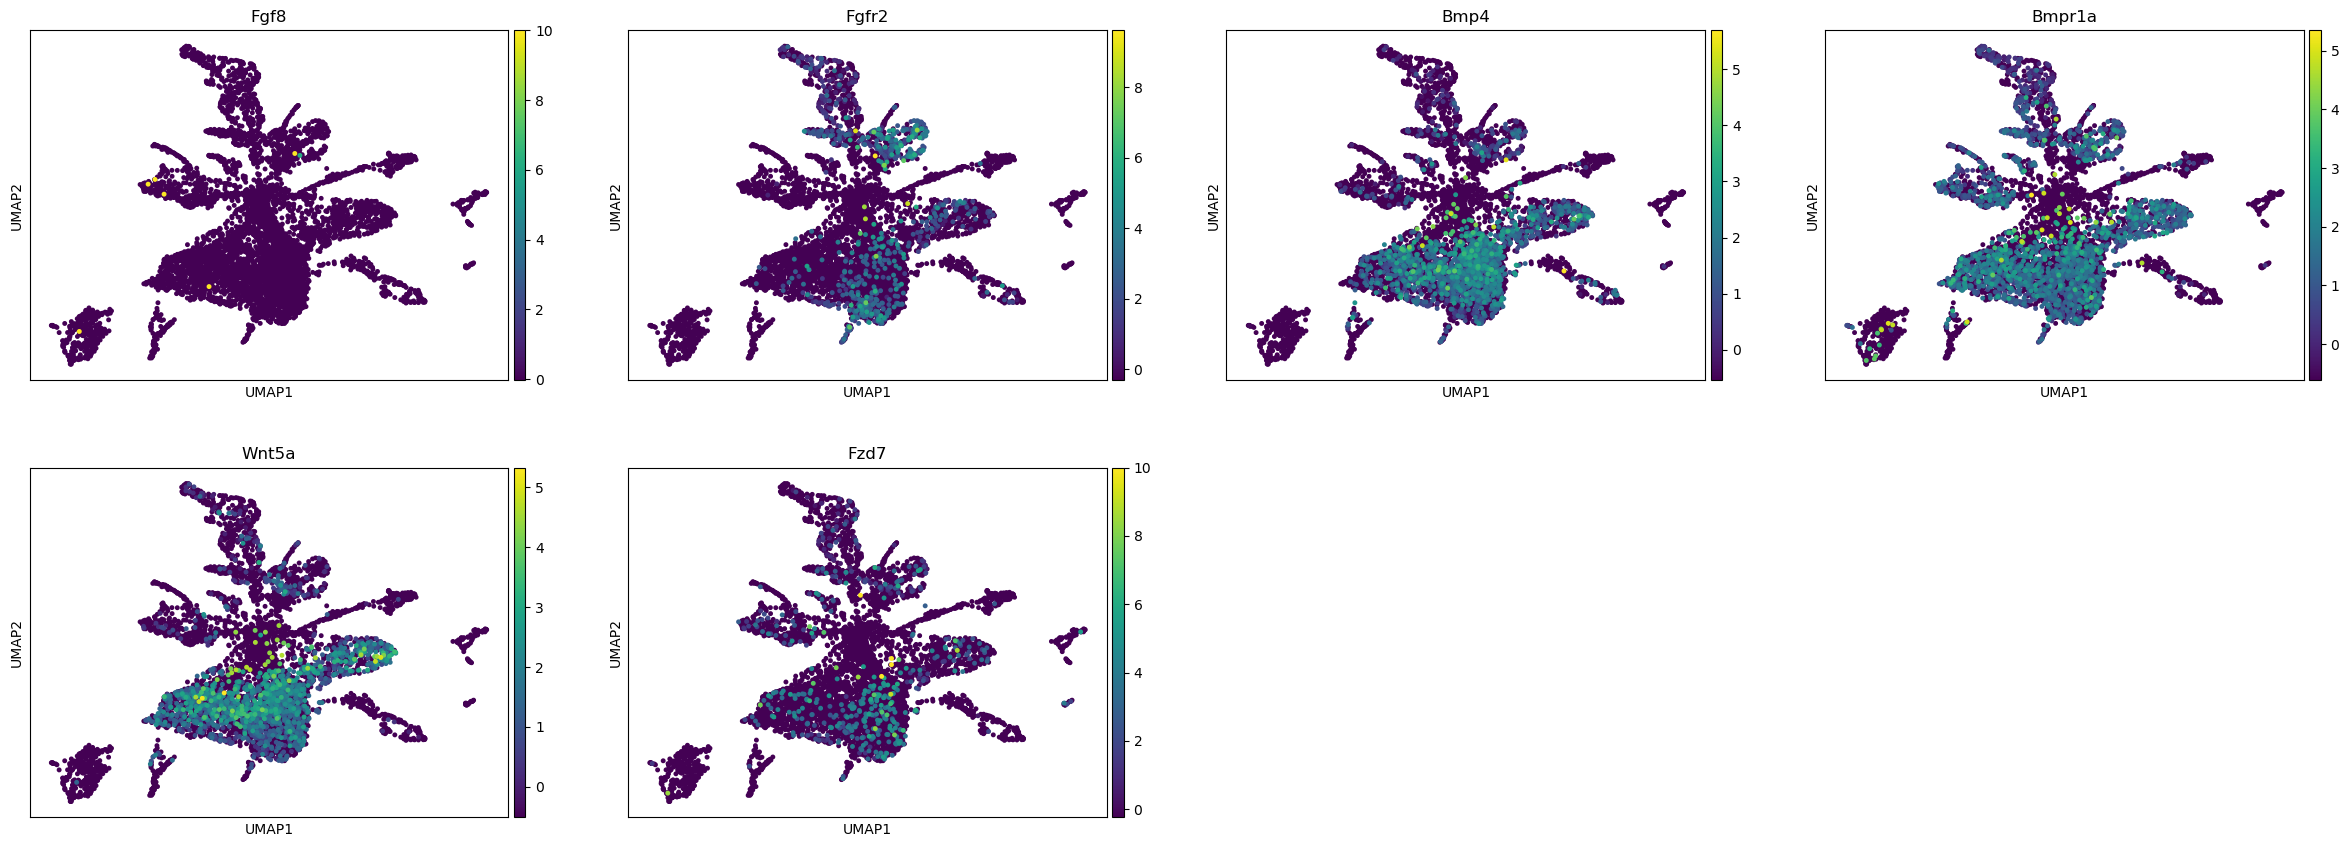

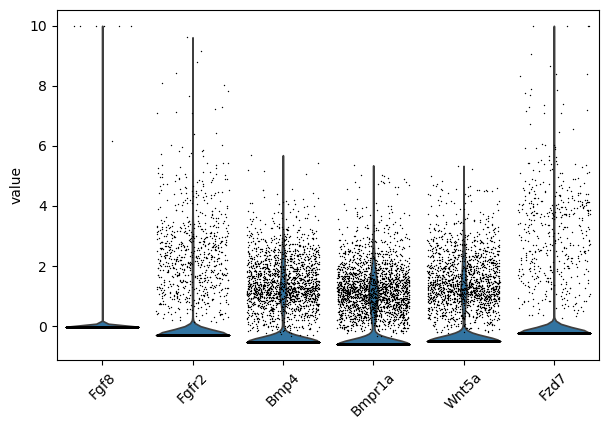

In [65]:
#list genes of interest 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in my Anndata object 
for gene in genes_of_interest: 
    if gene not in adata_3.var_names: 
        print(f"{gene} not found")
    else: 
        print(f"{gene} found")

#Visualize expression of the genes on the UMAP
sc.pl.umap(adata_3, color=genes_of_interest, cmap='viridis', size=50)

#Violin plot show distribution of expression per gene
sc.pl.violin(adata_3, genes_of_interest, jitter=0.4, rotation=45)

     Gene  AverageExpression
0    Fgf8      -1.669735e-02
1   Fgfr2       2.147628e-18
2    Bmp4      -5.556988e-17
3  Bmpr1a       1.288577e-17
4   Wnt5a      -4.832163e-18
5    Fzd7      -6.794515e-04


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_27132/1900320681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gene', y='AverageExpression', data=avg_expr_df, palette='viridis', legend=False)


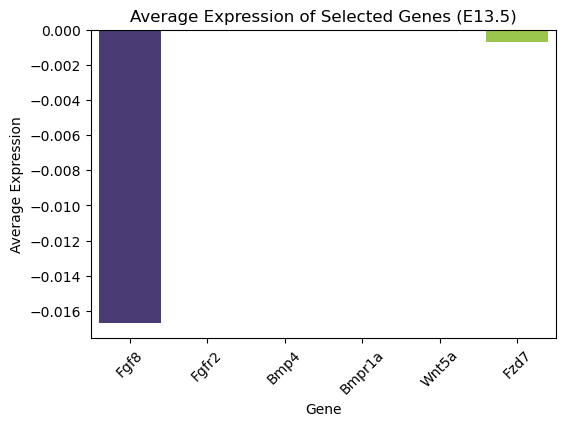

In [66]:
# calculate mean expression for each gene in list 
avg_expression = adata_3[:, genes_of_interest].X.mean(axis=0)

#convert to a pandas Dataframe for easy viewing 
avg_expr_df = pd.DataFrame({'Gene': genes_of_interest, 'AverageExpression': avg_expression.flatten()})

print(avg_expr_df)

#optional barplot for easy viewing 

plt.figure(figsize=(6,4))
sns.barplot(x='Gene', y='AverageExpression', data=avg_expr_df, palette='viridis', legend=False)

plt.title('Average Expression of Selected Genes (E13.5)')
plt.ylabel('Average Expression')
plt.xlabel('Gene')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# integrating all results from 13.5, 14.5, and 15.5 average expression of the selected genes 

    

#statistical testing of gene clusters of each stage
    - # t-test/mann whitney? 



# change the umaps so you have 3 umaps in total, showing the expression the selected genes across different stages
# ^ 3 umaps of all stages showing cell type per cluster 

Updated Task/ Workflow Overview 

Goal: Compare cell types and craniofacial pathway gene expression across E13.5, E14.5, and E15.5 soft palate 

1. Import packages- scanpy, pandas, numpy, matplotlib, seaborn
2. Load each sample - 13.5, 14.5 ,15.5
3. Quality control
   - Remove low-quality cells:
         - keep cells less than 200 genes, remove cells move then 2500-3000 genes
     -Remove low-quality genes:
         - keep genes expressed in at least 3 cells
     
4. Normalize and log-transform
   - normalize total counts per cell (target sum = 10,000)
   - log-transfrom to stabilize variance
5. Highly variable genes and scaling
   - identift top 2000 highly variable genes
   - scale data (mean 0, variance 1, max value = 10)
6. Clustering & UMAP
   - Cluster cells
   - Visualize clusters with UMAP
7. Assign broad cell types (marker-based)
   - small, high-confidence marker list:
         - Mesenchymal: Pdgfra, Col1a1, Dlk1
         - Epithelial: Krt8,Krt19. Epcam
         - Endothelial: Pecam1, Cdh5, Kdr
         - Osteogenic : Runx2. Sp7, Alpl
8. Examine genes of interest
   - FGF: Fgf8, Fgfr2
   - BMP: Bmp4, Bmpr1a
   - Wnt: Wnt5a, Fzd7
9. Statistical analysis
   1. Cluster proportions across stages - Chi-square test
   2. Gene expression across stages (within cluster) - One- way ANOVA or Kruskal-Wallis
   3. Optional: Wilcoxon rank-sum for pairwise stage comparisons
10. Visualizations
    -UMAP plots with clusters labeled
    - Stacked barplots showing proportion of each cell type per stage
    - Violin plots showing gene expression for your genes of interest per cluster/stage

In [3]:
# Step 1 

import scanpy as sc
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Step 2 

adata_13 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE135control",  
    var_names='gene_symbols', cache=True)

print(adata_13)

AnnData object with n_obs × n_vars = 7381 × 31053
    var: 'gene_ids', 'feature_types'


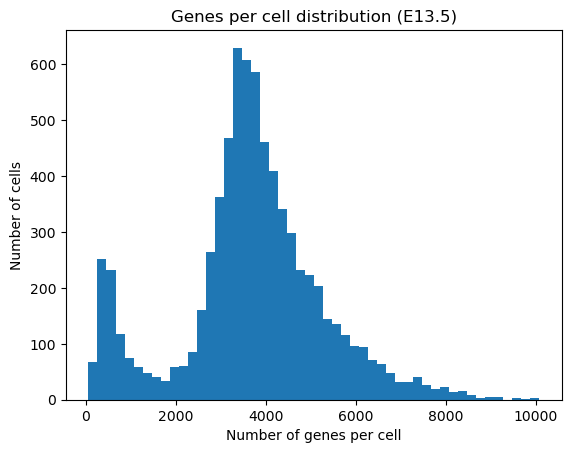

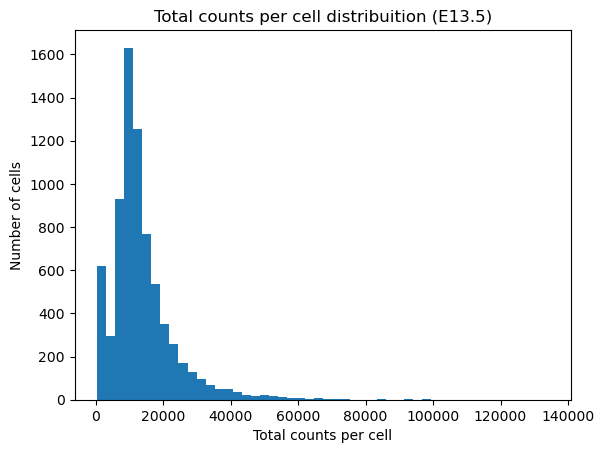

In [6]:
# Step 3

sc.pp.calculate_qc_metrics(adata_13, inplace=True)

#visualize the distribtions 
plt.hist(adata_13.obs['n_genes_by_counts'], bins= 50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells')
plt.title('Genes per cell distribution (E13.5)')
plt.show()

plt.hist(adata_13.obs['total_counts'], bins=50)
plt.xlabel('Total counts per cell')
plt.ylabel('Number of cells')
plt.title('Total counts per cell distribuition (E13.5)')
plt.show()

In [7]:
#keep cells with 200-2500 genes 
adata_13 = adata_13[adata_13.obs['n_genes_by_counts'] >= 200, :]
adata_13 = adata_13[adata_13.obs['n_genes_by_counts'] >= 2500, :]

#keep genes expressed in at least 3 cells 
adata_13 = adata_13[:, adata_13.var['n_cells_by_counts'] >= 3]

print(adata_13) 

View of AnnData object with n_obs × n_vars = 6225 × 19463
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


In [8]:
#step 4 

#scales each cell to have the same total counts (10,000 is standard)
sc.pp.normalize_total(adata_13, target_sum=1e4)

#log-transform the counts to stabilize variance 
sc.pp.log1p(adata_13)

print(adata_13.X[:5,:5])

/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2 stored elements and shape (5, 5)>
  Coords	Values
  (0, 3)	0.6580442190170288
  (3, 3)	0.6865628957748413


In [13]:
#step 5a - identify highly variable genes

#select the top 2000 genes that vary the most across cells 
sc.pp.highly_variable_genes(adata_13, n_top_genes=2000)

#keep only highly variable genes for downstream analysis 
adata_13 = adata_13[:, adata_13.var['highly_variable']]

#step 5b- scale the data

#centers each gene to mean 0 and variance 1 
#max value=10 prevents extremely high values from skewing results 
sc.pp.scale(adata_13, max_value= 10) 

print(adata_13.X[:5, :5])


#highly variable genes: focus on genes that matter the most for distinguishing cell types 
#scaling: prevents highly expressed genes from dominating clustering 


[[-0.08193497  0.84273143  1.12897132 -0.12744997  3.09564164]
 [-0.08193497  0.48616582 -0.55288736 -0.12744997 -0.67831105]
 [-0.08193497 -0.83819971 -0.55288736 -0.12744997  1.54309558]
 [-0.08193497 -0.83819971 -0.55288736 -0.12744997  0.8172041 ]
 [-0.08193497 -0.83819971 -0.55288736 -0.12744997 -0.67831105]]


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_highly_variable_genes.py:744: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [15]:
!pip install leidenalg



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.8 MB/s eta 0:00:00


[0.06101341 0.04614415 0.0335571  0.0312744  0.02610862 0.0235709
 0.0199055  0.01800215 0.01692708 0.01293622]
leiden
0     743
1     688
2     524
3     484
4     469
5     446
6     422
7     351
9     342
8     342
10    334
11    317
12    218
13    147
14    147
15     87
16     86
17     78
Name: count, dtype: int64


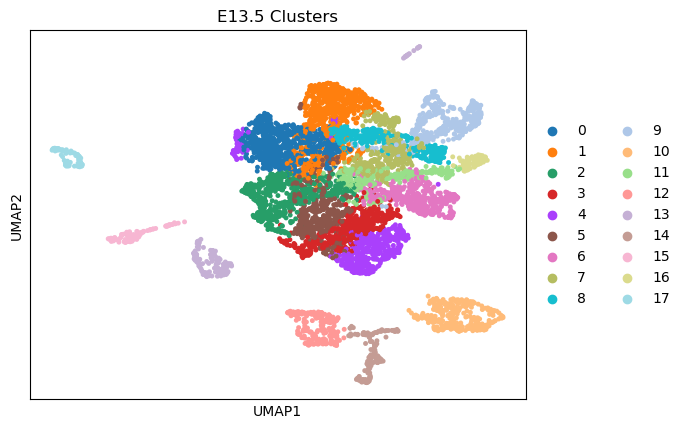

In [17]:
#step 6a- PCA

#PCA reduces the high-dimensional data to a smaller number of components 
sc.tl.pca(adata_13, svd_solver='arpack')

#look at variance explained by the first few PCs
print(adata_13.uns['pca']['variance_ratio'][:10])


#step 6b- compute neighborhood graph 

#defines which cells are neighbors based on PCA
#n_neighbors = 10 (standard for small datasets) 
#n_pcs = 20 (uses first 20 principal components)

sc.pp.neighbors(adata_13, n_neighbors=10, n_pcs=20)

#step 6c- clustering cells
sc.tl.leiden(adata_13, resolution=0.5)

#check the clustrer assignments 
print(adata_13.obs['leiden'].value_counts())

#step 5d UMAP 
sc.tl.umap(adata_13)

#plot UMAP by cluster 
sc.pl.umap(adata_13, color='leiden', size=50, title='E13.5 Clusters') 


In [21]:
#step 7 

#define a smaller marker dictionary for major cell types 
marker_dict = {
    'Epithelial': ['Krt14', 'Krt5'],
    'Mesenchymal': ['Prrx1', 'Twist1'],
    'Endothelial': ['Pecam1', 'Cdh5'],
    'Immune': ['Ptprc'],
    'NeuralCrest': ['Sox10', 'Foxd3']
}


#calculate average expression per cluster 

#create a new column with cluster labels as integers 
adata_13.obs['cluster'] = adata_13.obs['leiden'].astype(int)

#creat a dictionary to store cluster -> cell type assignments 
cluster_celltype = {}

# loop through clusters 
for cluster in adata_13.obs['cluster'].unique(): 
    cluster_cells = adata_13[adata_13.obs['cluster'] == cluster]
    avg_exp_per_type = {}
    for cell_type, genes in marker_dict.items():
        genes_present = [g for g in genes if g in cluster_cells.var_names]
        if len(genes_present)  > 0:
            avg_exp = cluster_cells[:, genes_present].X.mean()
            avg_exp_per_type[cell_type] = avg_exp
        else: 
            avg_exp_per_type[cell_type] = 0 
    assigned_type = max(avg_exp_per_type, key=avg_exp_per_type.get)
    cluster_celltype[cluster] = assigned_type

print(cluster_celltype)

{np.int64(6): 'Endothelial', np.int64(7): 'Mesenchymal', np.int64(16): 'Endothelial', np.int64(0): 'Mesenchymal', np.int64(17): 'Endothelial', np.int64(4): 'Mesenchymal', np.int64(5): 'Mesenchymal', np.int64(2): 'Mesenchymal', np.int64(1): 'Mesenchymal', np.int64(3): 'Mesenchymal', np.int64(9): 'NeuralCrest', np.int64(11): 'Immune', np.int64(10): 'Epithelial', np.int64(8): 'Endothelial', np.int64(13): 'Endothelial', np.int64(15): 'Immune', np.int64(14): 'NeuralCrest', np.int64(12): 'NeuralCrest'}


cell_type
Mesenchymal    3705
Endothelial    1075
NeuralCrest     707
Immune          404
Epithelial      334
Name: count, dtype: int64


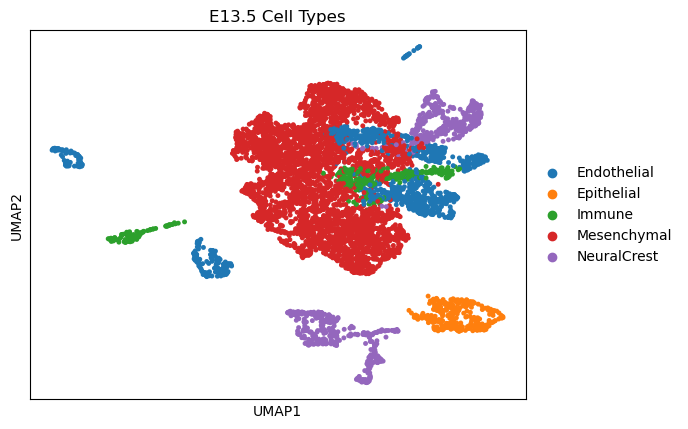

In [23]:
#map cluster number to assigned cell type 
adata_13.obs['cell_type'] = adata_13.obs['cluster'].map(cluster_celltype)

print(adata_13.obs['cell_type'].value_counts())

sc.pl.umap(adata_13, color='cell_type', size=50, title='E13.5 Cell Types') 


In [26]:
#check how many cells have a label
labeled_cells = adata_13.obs['cell_type'].notna().sum()
unlabeled_cells = adata_13.obs['cell_type'].isna().sum()
total_cells = adata_13.n_obs

print(f"Total cells: {total_cells}")
print(f"Labeled cells: {labeled_cells}")
print(f"Unlabeled cells: {unlabeled_cells}")

print(f"Percentage labeled: {labeled_cells/total_cells*100:.2f}%")
print(f"Percentage unlabeled: {unlabeled_cells/total_cells*100:.2f}%")

Total cells: 6225
Labeled cells: 6225
Unlabeled cells: 0
Percentage labeled: 100.00%
Percentage unlabeled: 0.00%


In [27]:
#step 8 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in the dataset
existing_genes = [g for g in genes_of_interest if g in adata_13.var_names]
print("Genes found in dataset:", existing_genes)

#calculate average expression per cell type 
avg_exp_per_type = adata_13.to_df()[existing_genes].groupby(adata_13.obs['cell_type']).mean()

print(avg_exp_per_type)

Genes found in dataset: ['Fgf8', 'Fgfr2', 'Bmp4', 'Wnt5a']
                 Fgf8     Fgfr2      Bmp4     Wnt5a
cell_type                                          
Endothelial -0.094693 -0.330036 -0.212929 -0.015704
Epithelial   1.085956  0.758519 -0.376310 -0.373360
Immune      -0.058312 -0.504565 -0.187476 -0.219614
Mesenchymal -0.084426 -0.008447  0.197495  0.110318
NeuralCrest -0.002055  0.476076 -0.426299 -0.252365


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_68551/3046839717.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_exp_per_type = adata_13.to_df()[existing_genes].groupby(adata_13.obs['cell_type']).mean()


In [30]:
#step 8a- statistical analysis 
    #One way ANOVA- compare average expression of a gene across multiple cell types 
    # chi-sqaured test - compare porportions of cells expressing a gene (expressed vs not expressed) across cell types 

from scipy.stats import f_oneway 

#create a list of arrays, each array is the expression of Fgfr8 in one cell type 
expr_lists = [adata_13[adata_13.obs['cell_type'] == ct][:, 'Fgf8'].X.flatten() for ct in adata_13.obs['cell_type'].unique() if 'Fgf8' in adata_13.var_names]


#ANOVA
anova_result = f_oneway(*expr_lists)
print("One-way ANOVA result for Fgf8:", anova_result)

One-way ANOVA result for Fgf8: F_onewayResult(statistic=np.float64(190.42381560464096), pvalue=np.float64(3.173884802571735e-154))


In [31]:

adata_14 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE145control",  
    var_names='gene_symbols', cache=True)